# Workshop 2 – Machine Learning & Deep Learning Aplicado
## Problema 2: Estimación de Edad a partir de Imágenes Faciales

**Universidad EAFIT – Introducción a la Inteligencia Artificial**  
Autores: Abraham Navarro· David Rodriguez

---

## Configuración del entorno

> **Instrucciones para ejecutar:** Montar Google Drive con el dataset descargado de  
> `kaggle.com/datasets/arashnic/faces-age-detection-dataset`  
> Estructura esperada en Drive: `MyDrive/Faces-Age-Detection/faces/Train/` e `train.csv`

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ── Librerías ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ── Rutas ──────────────────────────────────────────────────────────────────
DATASET_PATH = "/content/drive/MyDrive/Faces-Age-Detection/faces/Train"
CSV_PATH     = "/content/drive/MyDrive/Faces-Age-Detection/faces/train.csv"
IMG_SIZE     = 64

# Verificar que las rutas existen
print("Imágenes encontradas:", len(os.listdir(DATASET_PATH)))
print("Ejemplo:", os.listdir(DATASET_PATH)[:5])

Imágenes encontradas: 19906
Ejemplo: ['8834.jpg', '8781.jpg', '8819.jpg', '878.jpg', '8764.jpg']


## 1. Análisis Preliminar del Problema

### a) ¿Por qué es un problema de regresión?

La estimación de edad es un problema de **regresión** porque la variable objetivo (edad) es una cantidad **continua y numérica**. A diferencia de la clasificación —donde el modelo elige entre etiquetas discretas como YOUNG, MIDDLE, OLD— la regresión produce un valor escalar (ej: 27.4 años) evaluable con métricas de error como MAE o RMSE.

**Variable objetivo (target):** Edad aproximada en años (valor numérico continuo).

> **Nota sobre este dataset:** El CSV provee etiquetas categóricas (YOUNG, MIDDLE, OLD). Para convertirlo en regresión, mapeamos cada categoría a su valor representativo de edad:
> - `YOUNG`  → 15–30 años →
> - `MIDDLE` → 31–55 años →
> - `OLD`    → 56+ años   →

### b) Características de entrada

- **Tipo de datos:** Imágenes faciales en color (RGB)
- **Dimensiones originales:** Variables según la fuente
- **Espacio de color:** BGR (OpenCV) → convertido a RGB
- **Preprocesamiento:** Redimensionamiento a 128×128 px, normalización a [0,1]
- **Distribución de edades:** Sesgada hacia adultos jóvenes (clase YOUNG dominante)

### c) Protocolo de adquisición de datos

El dataset fue recopilado de imágenes faciales de actores y actrices, etiquetadas manualmente según rangos de edad. Las imágenes provienen de diversas fuentes públicas y cubren variación en iluminación, pose, expresión y etnia. Las etiquetas (YOUNG/MIDDLE/OLD) fueron asignadas por anotadores humanos siguiendo rangos etarios definidos.

## 2. Análisis Exploratorio de Datos (EDA)

In [5]:
# ── Leer CSV ───────────────────────────────────────────────────────────────
# El CSV tiene columnas: ID (nombre archivo) y Class (YOUNG/MIDDLE/OLD)
df = pd.read_csv(CSV_PATH)
df.columns = df.columns.str.strip()
df["Class"] = df["Class"].str.strip().str.upper()

print("Shape del CSV:", df.shape)
print("\nPrimeras filas:")
display(df.head())
print("\nDistribución de clases:")
print(df["Class"].value_counts())

Shape del CSV: (19906, 2)

Primeras filas:


,ID,Class
0,377.jpg,MIDDLE
1,17814.jpg,YOUNG
2,21283.jpg,MIDDLE
3,16496.jpg,YOUNG
4,4487.jpg,MIDDLE



Distribución de clases:
Class
MIDDLE    10804
YOUNG      6706
OLD        2396
Name: count, dtype: int64


# Primero revisamos cómo están distribuidas las clases en el dataset

In [6]:
#age map

import random

AGE_MAP = {
    "YOUNG":  (15, 30),
    "MIDDLE": (31, 55),
    "OLD":    (56, 80)
}

def age_from_class(label):
    low, high = AGE_MAP[label]
    return random.randint(low, high)

df["age"] = df["Class"].apply(age_from_class)

assert df["age"].isna().sum() == 0, "Hay etiquetas no mapeadas"
print("Estadísticos del target (edad):")
print(df["age"].describe())

Estadísticos del target (edad):
count    19906.00000
mean        39.10007
std         15.60132
min         15.00000
25%         26.00000
50%         38.00000
75%         49.00000
max         80.00000
Name: age, dtype: float64


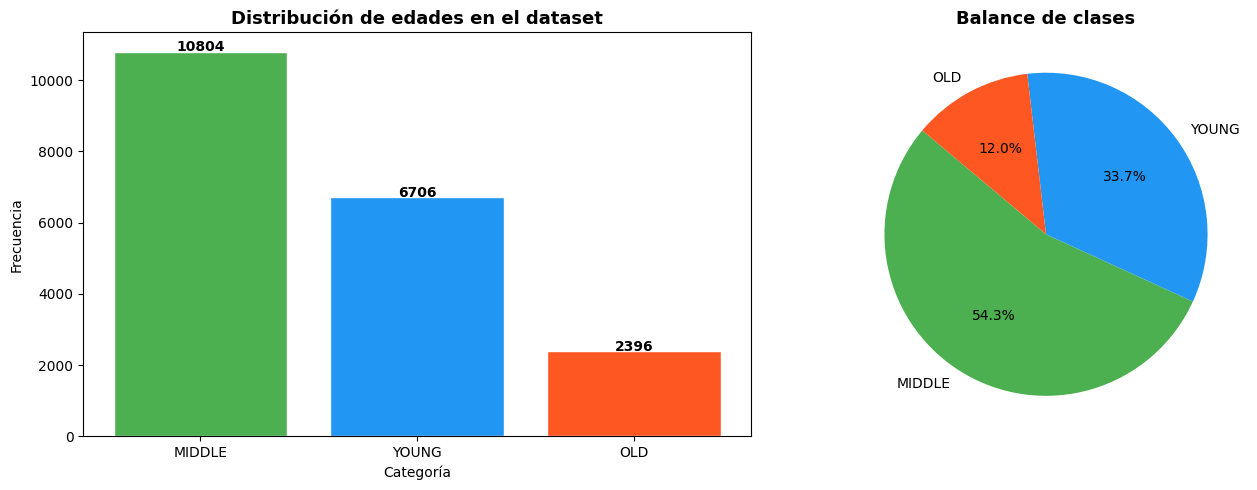


Interpretación:
- El dataset muestra desequilibrio de clases. Si YOUNG domina, el modelo
  tenderá a subestimar edades en rangos MIDDLE/OLD (sesgo hacia valores bajos).
- Al convertir a regresión con valores representativos, el target queda
  concentrado en 3 puntos , lo cual es una simplificación
  necesaria dado el formato del dataset.



In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df["Class"].value_counts()
labels = counts.index.tolist()
colors = ["#4CAF50", "#2196F3", "#FF5722"]

axes[0].bar(labels, counts.values, color=colors, edgecolor="white")
axes[0].set_title("Distribución de edades en el dataset", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Categoría")
axes[0].set_ylabel("Frecuencia")
for label, count in zip(labels, counts.values):
    axes[0].text(label, count + 10, str(count), ha="center", fontweight="bold")

axes[1].pie(counts.values, labels=labels, autopct="%1.1f%%",
            colors=colors, startangle=140)
axes[1].set_title("Balance de clases", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

print("""
Interpretación:
- El dataset muestra desequilibrio de clases. Si YOUNG domina, el modelo
  tenderá a subestimar edades en rangos MIDDLE/OLD (sesgo hacia valores bajos).
- Al convertir a regresión con valores representativos, el target queda
  concentrado en 3 puntos , lo cual es una simplificación
  necesaria dado el formato del dataset.
""")

In [8]:
# Carga de imágenes (muestra para EDA)
images_raw = []
ages_raw   = []
failed     = 0

for _, row in df.sample(2500, random_state=42).reset_index(drop=True).iterrows():
    img_path = os.path.join(DATASET_PATH, row["ID"])
    img = cv2.imread(img_path)
    if img is None:
        failed += 1
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images_raw.append(img_rgb)
    ages_raw.append(row["age"])

ages_raw = np.array(ages_raw)
print(f"Imágenes cargadas: {len(images_raw)}")
print(f"Imágenes no encontradas: {failed}")

Imágenes cargadas: 2500
Imágenes no encontradas: 0


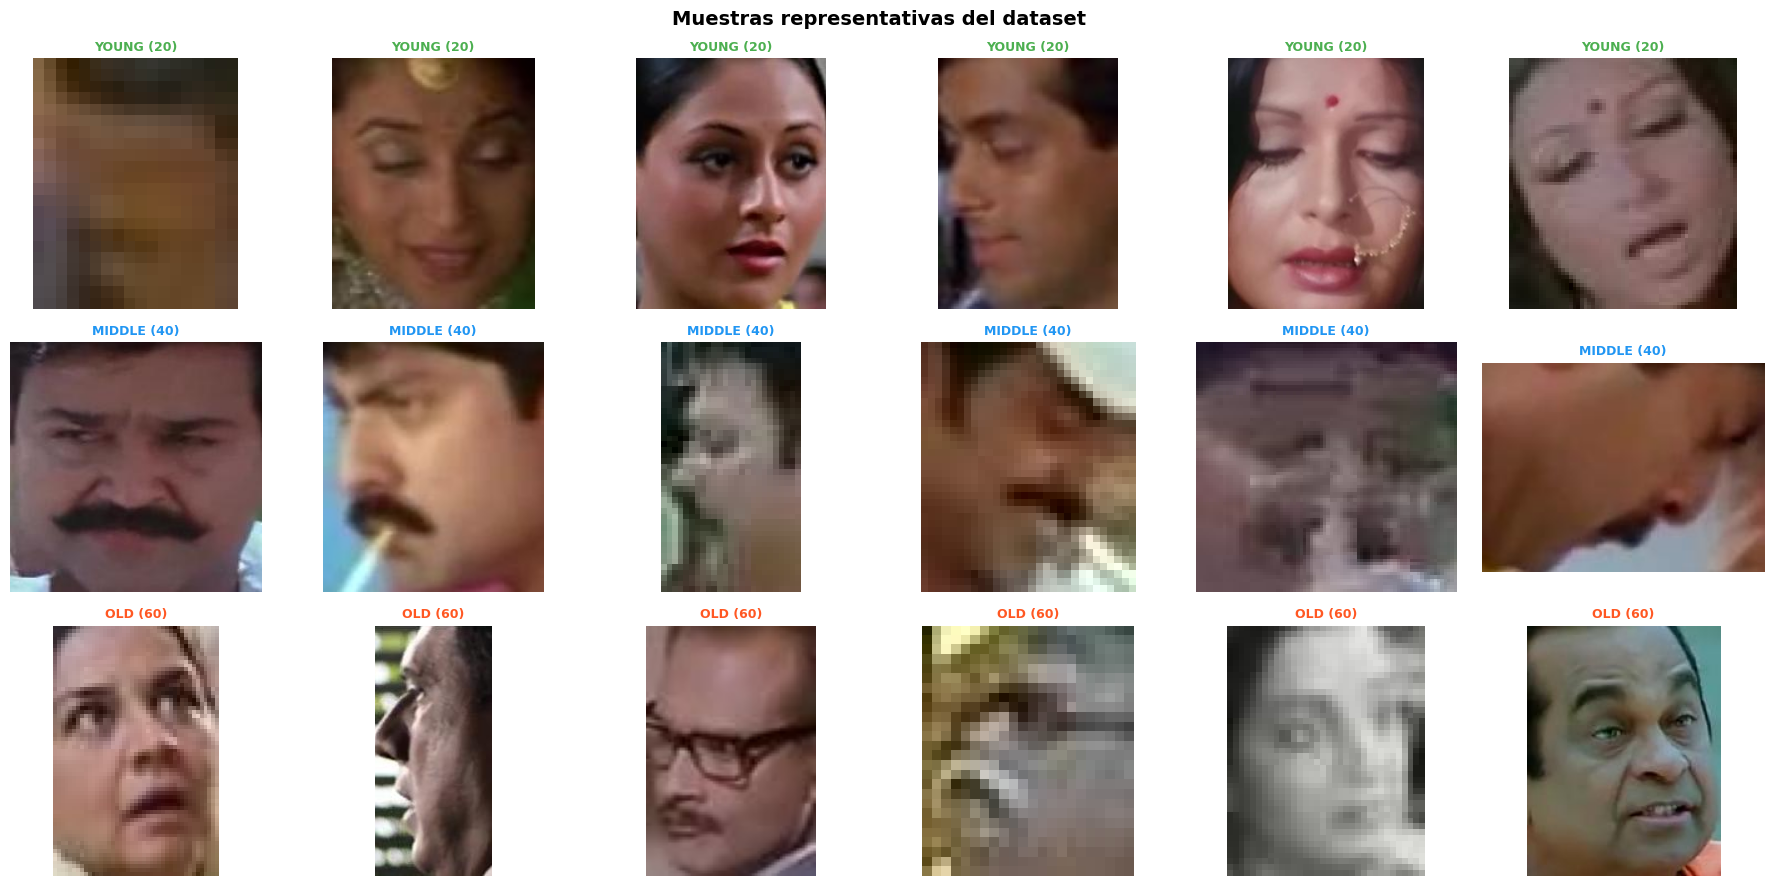


Interpretación:
- Se observan diferencias visuales claras entre rangos etarios: arrugas,
  textura de piel, cabello y geometría facial cambian con la edad.
- Hay variación en iluminación, pose y resolución, lo que añade dificultad
  al modelo y justifica el uso de data augmentation.



In [9]:
#  Visualización de muestras representativas
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle("Muestras representativas del dataset", fontsize=14, fontweight="bold")

label_names = {20: "YOUNG (20)", 40: "MIDDLE (40)", 60: "OLD (60)"}
colors      = {20: "#4CAF50",   40: "#2196F3",      60: "#FF5722"}

for row_idx, age_val in enumerate([20, 40, 60]):
    idxs = np.where(ages_raw == age_val)[0][:6]
    for col_idx, img_idx in enumerate(idxs):
        ax = axes[row_idx, col_idx]
        ax.imshow(images_raw[img_idx])
        ax.set_title(label_names[age_val], fontsize=9,
                     color=colors[age_val], fontweight="bold")
        ax.axis("off")

plt.tight_layout()
plt.show()

print("""
Interpretación:
- Se observan diferencias visuales claras entre rangos etarios: arrugas,
  textura de piel, cabello y geometría facial cambian con la edad.
- Hay variación en iluminación, pose y resolución, lo que añade dificultad
  al modelo y justifica el uso de data augmentation.
""")

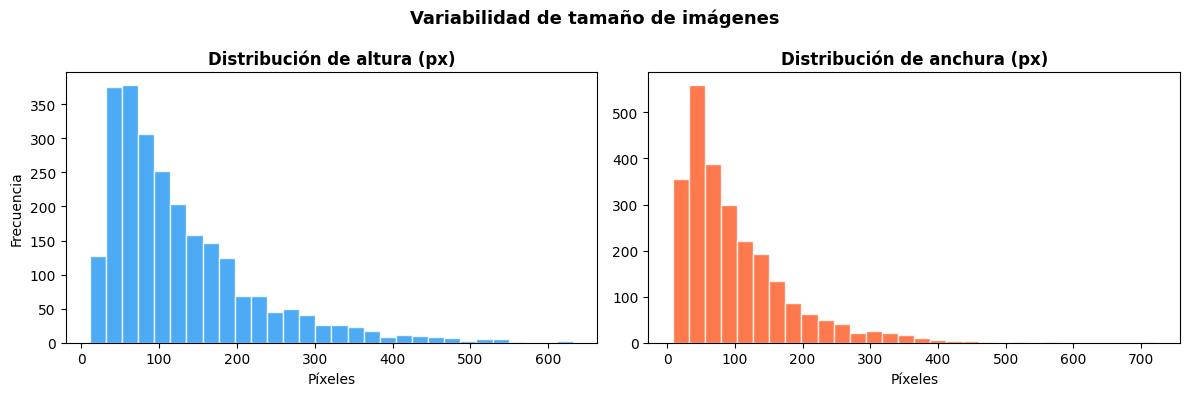

Altura  – min: 11, max: 632, media: 126.4
Anchura – min: 8,  max: 722,  media: 99.7

Interpretación:
- Las imágenes tienen tamaños heterogéneos, por lo que el redimensionamiento
  a 128x128 px es indispensable para alimentar la CNN.
- La variabilidad en resolución puede afectar la calidad de características
  extraídas en imágenes de baja resolución.



In [10]:
#  Análisis de calidad y variabilidad de imágenes
heights = [img.shape[0] for img in images_raw]
widths  = [img.shape[1] for img in images_raw]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(heights, bins=30, color="#2196F3", edgecolor="white", alpha=0.8)
axes[0].set_title("Distribución de altura (px)", fontweight="bold")
axes[0].set_xlabel("Píxeles")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(widths, bins=30, color="#FF5722", edgecolor="white", alpha=0.8)
axes[1].set_title("Distribución de anchura (px)", fontweight="bold")
axes[1].set_xlabel("Píxeles")

plt.suptitle("Variabilidad de tamaño de imágenes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Altura  – min: {min(heights)}, max: {max(heights)}, media: {np.mean(heights):.1f}")
print(f"Anchura – min: {min(widths)},  max: {max(widths)},  media: {np.mean(widths):.1f}")
print("""
Interpretación:
- Las imágenes tienen tamaños heterogéneos, por lo que el redimensionamiento
  a 128x128 px es indispensable para alimentar la CNN.
- La variabilidad en resolución puede afectar la calidad de características
  extraídas en imágenes de baja resolución.
""")

## 3. Procesamiento de Datos

In [11]:
#  función para limpiar y preparar las imágenes antes de entrenar
def preprocess_image(img_rgb, target_size=(IMG_SIZE, IMG_SIZE)):
    """
    Pipeline:
    1. Redimensionar a target_size
    2. Normalizar pixeles a [0, 1]
    3. Verificar 3 canales RGB
    """
    img = cv2.resize(img_rgb, target_size, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    assert img.shape == (target_size[0], target_size[1], 3)
    return img

processed_images = np.array([preprocess_image(img) for img in images_raw])
ages_array       = ages_raw.astype(np.float32)

print("Shape imágenes procesadas:", processed_images.shape)
print("Rango de valores:", processed_images.min(), "–", processed_images.max())

Shape imágenes procesadas: (2500, 64, 64, 3)
Rango de valores: 0.0 – 1.0


In [12]:
#  División train / val / test (70 / 15 / 15)
# Justificación: 70% garantiza suficientes datos de entrenamiento;
# 15% val permite ajustar hiperparámetros sin contaminar el test;
# 15% test da una estimación imparcial del rendimiento final.

X_train, X_temp, y_train, y_temp = train_test_split(
    processed_images, ages_array, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train : {X_train.shape[0]} muestras")
print(f"Val   : {X_val.shape[0]} muestras")
print(f"Test  : {X_test.shape[0]} muestras")

Train : 1750 muestras
Val   : 375 muestras
Test  : 375 muestras


In [13]:
#  Data Augmentation
# Justificación: la variabilidad en pose e iluminación del dataset hace
# que el augmentation reduzca el overfitting y mejore la generalización.
# Solo se aplica al conjunto de entrenamiento.

datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05
)
datagen.fit(X_train)
print("Data augmentation configurado correctamente.")

Data augmentation configurado correctamente.


## 4. Entrenamiento del Modelo CNN para Regresión

In [14]:
# Arquitectura CNN
# bloques convolucionales para extraer características de las imágenes
#   Filtros crecientes (32→64→128→256) capturan desde bordes hasta rasgos
#   complejos como arrugas y textura de piel.
# - BatchNormalization: estabiliza el entrenamiento y actúa como regularizador.
# - Dropout(0.4/0.3): evita overfitting en las capas densas.
# - Dense(1) SIN activación: salida continua irrestricta para regresión.

def build_model(input_shape=(128, 128, 3)):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1)  # regresión: sin activación
    ])

    # Huber Loss: más robusta que MSE ante outliers de edad
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.Huber(delta=10.0),
        metrics=['mae']
    )
    return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,153 (1.87 MB)

 Trainable params: 488,193 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [15]:
# ── Callbacks y entrenamiento ──────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_mae', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('mejor_modelo_edad.keras', monitor='val_mae', save_best_only=True, verbose=1)
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 226.3040 - mae: 27.3294
Epoch 1: val_mae improved from None to 38.77413, saving model to mejor_modelo_edad.keras

Epoch 1: finished saving model to mejor_modelo_edad.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - loss: 149.3471 - mae: 19.4140 - val_loss: 337.7413 - val_mae: 38.7741 - learning_rate: 0.0010
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 93.9165 - mae: 13.6731
Epoch 2: val_mae did not improve from 38.77413
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 96.3940 - mae: 13.9425 - val_loss: 338.7763 - val_mae: 38.8776 - learning_rate: 0.0010
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 90.5301 - mae: 13.2938
Epoch 3: val_mae improved from 38.77413 to 38.11951, saving model to mejor_modelo_edad.keras

Epoch 3: finished saving model to mejor_modelo_edad.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 91.1176 - mae: 13.3587 - val_loss: 331.1952 - val_mae: 38.1195 - learning_rate: 0.00

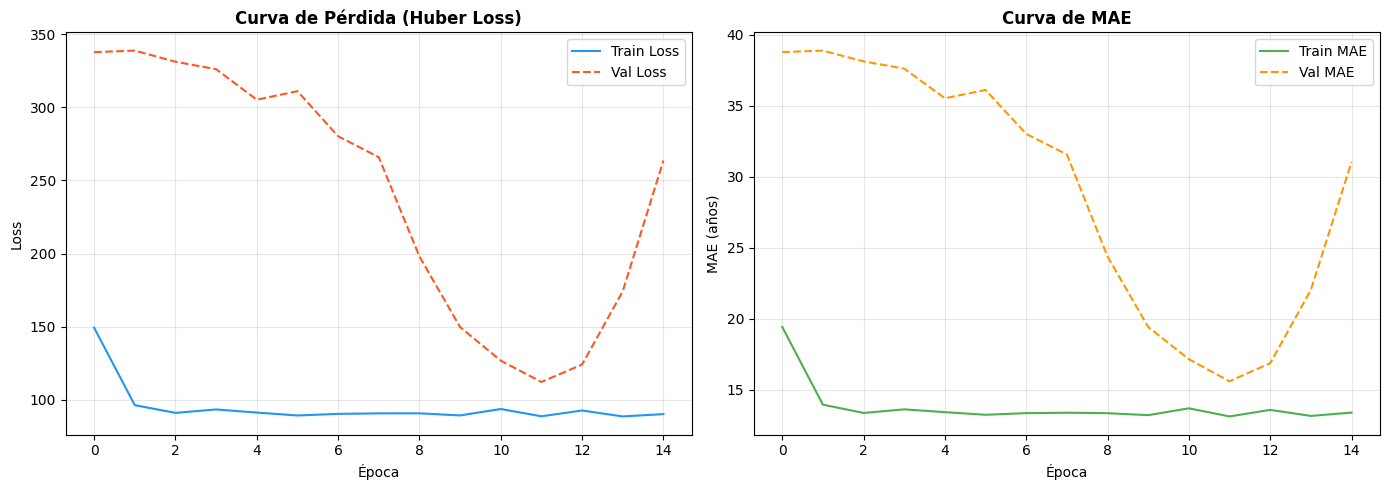


Interpretación:
- Si val_loss >> train_loss al final: OVERFITTING. El modelo memoriza
  los datos de entrenamiento. Solución: más Dropout, más augmentation.
- Si ambas curvas son altas y similares: UNDERFITTING. El modelo no
  aprende suficiente. Solución: más épocas o arquitectura más profunda.
- Si convergen suavemente: entrenamiento correcto.



In [16]:
#  Curvas de pérdida
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss',  color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Val Loss',    color='#FF5722', linestyle='--')
axes[0].set_title("Curva de Pérdida (Huber Loss)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train MAE', color='#4CAF50')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#FF9800', linestyle='--')
axes[1].set_title("Curva de MAE", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("MAE (años)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("""
Interpretación:
- Si val_loss >> train_loss al final: OVERFITTING. El modelo memoriza
  los datos de entrenamiento. Solución: , más augmentation.
- Si ambas curvas son altas y similares: UNDERFITTING. El modelo no
  aprende suficiente. Solución: más épocas o arquitectura más profunda.
- Si convergen suavemente: entrenamiento correcto.
""")

In [17]:
#  Métricas en train, val y test
def compute_metrics(y_true, y_pred, set_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f"  {set_name}")
    print(f"{'='*40}")
    print(f"  MAE  : {mae:.2f} años")
    print(f"  RMSE : {rmse:.2f} años")
    print(f"  R2   : {r2:.4f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

pred_train = model.predict(X_train).flatten()
pred_val   = model.predict(X_val).flatten()
pred_test  = model.predict(X_test).flatten()

m_train = compute_metrics(y_train, pred_train, "TRAIN")
m_val   = compute_metrics(y_val,   pred_val,   "VALIDATION")
m_test  = compute_metrics(y_test,  pred_test,  "TEST")

metrics_df = pd.DataFrame([m_train, m_val, m_test], index=["Train", "Val", "Test"])
print("\nResumen de métricas:")
print(metrics_df.round(3).to_string())

55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

  TRAIN
  MAE  : 15.59 años
  RMSE : 20.01 años
  R2   : -0.6963

  VALIDATION
  MAE  : 15.59 años
  RMSE : 19.38 años
  R2   : -0.7592

  TEST
  MAE  : 16.01 años
  RMSE : 20.23 años
  R2   : -0.6873

Resumen de métricas:
          MAE    RMSE     R2
Train  15.592  20.005 -0.696
Val    15.590  19.378 -0.759
Test   16.014  20.229 -0.687


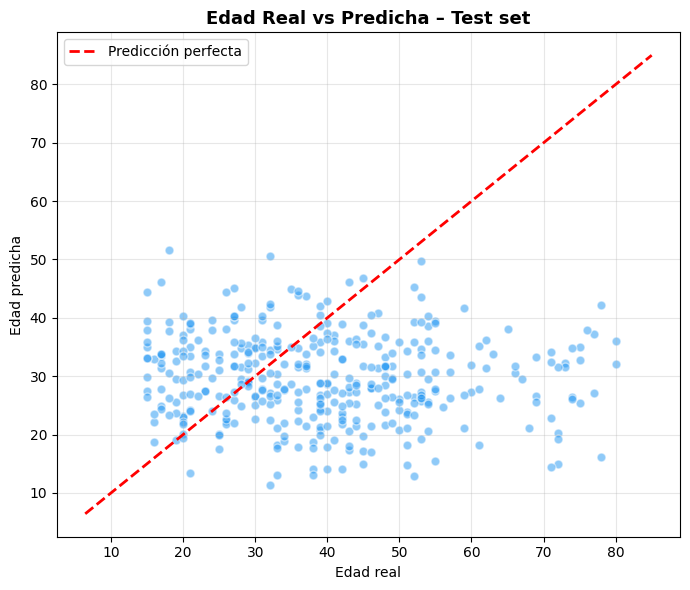

In [18]:
#  Gráfico real vs predicho
plt.figure(figsize=(7, 6))
plt.scatter(y_test, pred_test, alpha=0.5, color='#2196F3', edgecolors='white', s=40)
lims = [min(y_test.min(), pred_test.min()) - 5,
        max(y_test.max(), pred_test.max()) + 5]
plt.plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel("Edad real")
plt.ylabel("Edad predicha")
plt.title("Edad Real vs Predicha – Test set", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Prueba con Muestra Artificial

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step


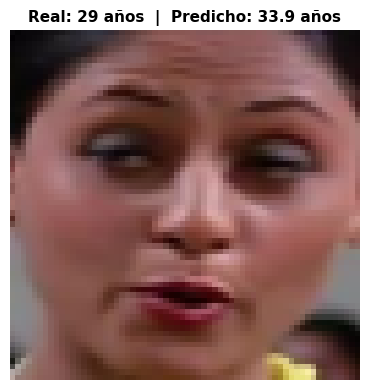

Edad real    : 29 años
Edad predicha: 33.9 años
Error        : 4.9 años


In [19]:
#  Prueba con una imagen del test set
idx = 0  # cambiar para probar distintas imágenes

test_img = X_test[idx]
real_age = y_test[idx]
pred_age = model.predict(np.expand_dims(test_img, axis=0))[0][0]

plt.figure(figsize=(4, 4))
plt.imshow(test_img)
plt.title(f"Real: {real_age:.0f} años  |  Predicho: {pred_age:.1f} años",
          fontsize=11, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Edad real    : {real_age:.0f} años")
print(f"Edad predicha: {pred_age:.1f} años")
print(f"Error        : {abs(pred_age - real_age):.1f} años")

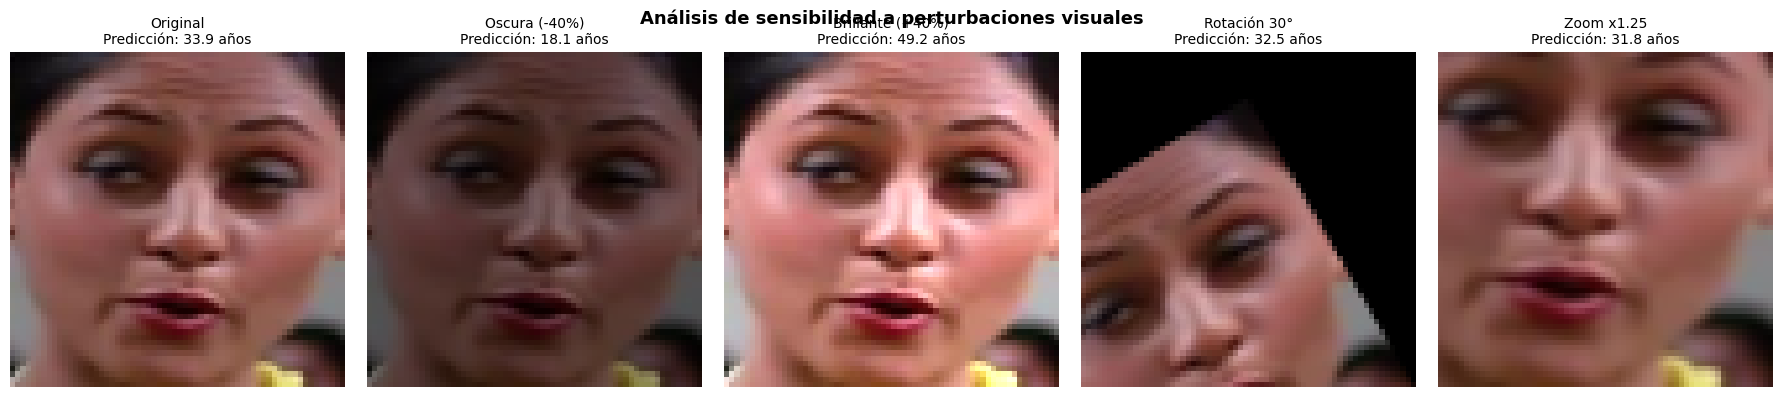


Análisis de sensibilidad:
- Iluminación: cambios en brillo alteran texturas que el modelo usa para
  detectar arrugas, lo que puede sub/sobreestimar la edad.
- Rotación: sin augmentation de rotación fuerte el modelo puede confundirse
  con orientaciones no vistas en entrenamiento.
- Zoom: eliminar contexto facial (frente, mentón) degrada la predicción.
- El data augmentation aplicado mitiga parcialmente estos efectos, pero
  el modelo no es completamente invariante a estas transformaciones.



In [20]:
#  Análisis de perturbaciones visuales
base    = (test_img * 255).astype(np.uint8)
dark    = np.clip(base * 0.6, 0, 255).astype(np.uint8)
bright  = np.clip(base * 1.4, 0, 255).astype(np.uint8)
M       = cv2.getRotationMatrix2D((64, 64), 30, 1.0)
rotated = cv2.warpAffine(base, M, (IMG_SIZE, IMG_SIZE))
crop    = base[13:115, 13:115]
zoomed  = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))

variants = [
    (base,    "Original"),
    (dark,    "Oscura (-40%)"),
    (bright,  "Brillante (+40%)"),
    (rotated, "Rotación 30°"),
    (zoomed,  "Zoom x1.25"),
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("sensibilidad visual",
             fontsize=13, fontweight='bold')

for ax, (img_uint8, name) in zip(axes, variants):
    img_norm = img_uint8.astype(np.float32) / 255.0
    pred = model.predict(np.expand_dims(img_norm, axis=0), verbose=0)[0][0]
    ax.imshow(img_uint8)
    ax.set_title(f"{name}\nPredicción: {pred:.1f} años", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("""
Análisis de sensibilidad:
- Iluminación: cambios en brillo alteran texturas que el modelo usa para
  detectar arrugas, lo que puede sub/sobreestimar la edad.
- Rotación: sin augmentation de rotación fuerte el modelo puede confundirse
  con orientaciones no vistas en entrenamiento.
- Zoom: eliminar contexto facial (frente, mentón) degrada la predicción.
- El data augmentation aplicado mitiga parcialmente estos efectos, pero
  el modelo no es completamente invariante a estas transformaciones.
""")